In [1]:
from scipy.stats import norm
import scipy.io as sio
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio
import numpy as np
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

########################################################################check SF3 in large scale ####################################
def sliding_window(total_length, window_size, step=1):
    """
    生成正确的滑动窗口切片（从0开始计数）
    """
    slices = []
    for start in range(0, total_length - window_size + 1, step):
        end = start + window_size - 1  # 结束索引是包含的
        slices.append((start, end))
    return slices
    
# 
from tqdm import tqdm
def check_SF3_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF3_L_tb=0
    SF3_T_tb=0
    SF3_L_lr=0
    SF3_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF3_L_tb=SF3_L_tb+dv**3
        SF3_T_tb=SF3_T_tb+dv*(du**2)
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF3_L_lr=SF3_L_lr+du**3
        SF3_T_lr=SF3_T_lr+du*(dv**2)
    
    SF3_L_tb=np.nanmean(SF3_L_tb/len(slices))
    SF3_T_tb=np.nanmean(SF3_T_tb/len(slices))
    SF3_L_lr=np.nanmean(SF3_L_lr/len(slices))
    SF3_T_lr=np.nanmean(SF3_T_lr/len(slices))
    R=xscale*window_size
    SF3_check=(SF3_L_tb+SF3_T_tb+SF3_L_lr+SF3_T_lr)/2
    return SF3_check, SF3_L_tb, SF3_T_tb, SF3_L_lr, SF3_T_lr,R


def check_SF1_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF1_L_tb=0
    SF1_T_tb=0
    SF1_L_lr=0
    SF1_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF1_L_tb=SF1_L_tb+dv
        SF1_T_tb=SF1_T_tb+du
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF1_L_lr=SF1_L_lr+du
        SF1_T_lr=SF1_T_lr+dv
    
    SF1_L_tb=np.nanmean(SF1_L_tb/len(slices))
    SF1_T_tb=np.nanmean(SF1_T_tb/len(slices))
    SF1_L_lr=np.nanmean(SF1_L_lr/len(slices))
    SF1_T_lr=np.nanmean(SF1_T_lr/len(slices))
    R=xscale*window_size
    SF1_L_check=(SF1_L_tb+SF1_L_lr)/2
    SF1_T_check=(SF1_T_tb+SF1_T_lr)/2
    return SF1_L_check, SF1_T_check,R

def get_sf3_bootstrap(data_dir,fname):
    data=sio.loadmat(data_dir+fname)
    sf3_mn=np.squeeze(data['SF3_mean'])
    sf3=np.squeeze(data['SF3'])
    sf3_std=np.squeeze(data['SF3_stderr'])
    dist_axis=np.squeeze(data['dist_axis'])
    sf3=sf3.T
    return sf3_mn,sf3,sf3_std,dist_axis

from scipy.stats import kurtosis, skew


def temporal_correlation_per_scale(SF1l, SF1t):
    """
    对每个尺度独立计算SF1l和SF1t的时间序列相关性
    输入: SF1l, SF1t - 形状为 (n_time, n_scales) 的数组
    输出: 每个尺度的Pearson相关系数数组
    """
    import numpy as np
    from scipy.stats import pearsonr
    
    n_time, n_scales = SF1l.shape
    correlation_by_scale = np.full(n_scales, np.nan)
    
    for scale_idx in range(n_scales):
        # 提取该尺度的时间序列
        sf1l_ts = SF1l[:, scale_idx]
        sf1t_ts = SF1t[:, scale_idx]
        
        # 移除NaN值
        valid_mask = ~(np.isnan(sf1l_ts) | np.isnan(sf1t_ts))
        sf1l_valid = sf1l_ts[valid_mask]
        sf1t_valid = sf1t_ts[valid_mask]
        
        # 确保有足够样本
        if len(sf1l_valid) >= 3:
            try:
                r_value, _ = pearsonr(sf1l_valid, sf1t_valid)
                correlation_by_scale[scale_idx] = r_value
            except:
                correlation_by_scale[scale_idx] = np.nan
    
    return correlation_by_scale


In [2]:
colorsmap = ['#0072BD', '#D95319', '#EDB120', '#7E2F8E', '#77AC30', '#4DBEEE']


# Load Eulerian SF3

In [3]:
import scipy.io as sio
# we=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave_Eulerian_SF3.mat')
# SF3_w_E=(we['S3L1_alltime']+we['S3T1_alltime'])
# SF3_w_E_std=(we['S3L1_alltime']+we['S3T1_alltime'])
# nwe=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave_Eulerian_SF3.mat')
# SF3_nw_E=(nwe['S3L1_alltime']+nwe['S3T1_alltime'])
# SF3_nw_E_std=(nwe['S3L1_alltime']+nwe['S3T1_alltime'])
# r1=sio.loadmat('/meddy/simingzhang/Analysis/matlab/r_e.mat')
# R=np.squeeze(r1['r'])

data=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/HIT2d_Eulerian_SF3.mat')
SF3=(data['S3L1_time']+data['S3T1_time'])
R=np.squeeze(data['r'])

In [4]:
SF3.shape

(199, 362)

In [5]:
D3bx = 0.55
D3b_bins = np.arange(-12, 12, D3bx)
iu2=20
# iu2=2
SF3_E_norm0 = norm.pdf(D3b_bins, np.nanmean(SF3[:,iu2])/np.nanstd(SF3[:,iu2]), 1)


In [6]:
R[iu2]

0.25157284921324513

Text(0, 0.4, 'r=0.25')

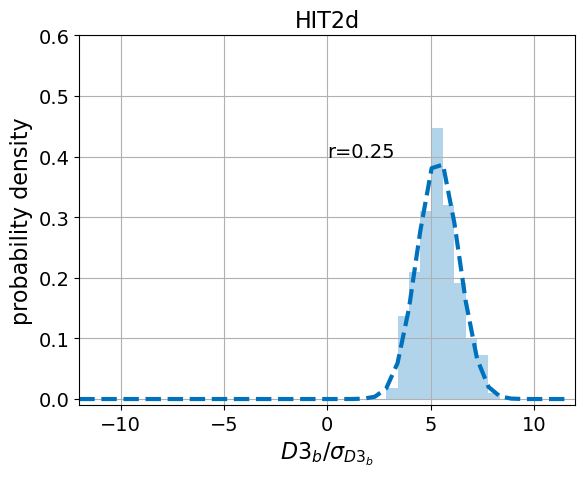

In [7]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
plt.plot(D3b_bins, SF3_E_norm0, linestyle='--',color=colorsmap[0],linewidth=3)
plt.hist((SF3[:,iu2])/np.nanstd(SF3[:,iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[0], label='Eulerian')
plt.ylim([-0.01,0.6])
plt.xlim([-12,12])
plt.ylabel(r'D1')
plt.xlabel(r'r')
plt.title(r'HIT2d')
plt.grid(True)
plt.xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
plt.ylabel(r'probability density')
plt.text(0,0.4,f'r=0.25')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_guassian.png', dpi=300, bbox_inches='tight')

Text(0, 0.5, 'Kurtosis')

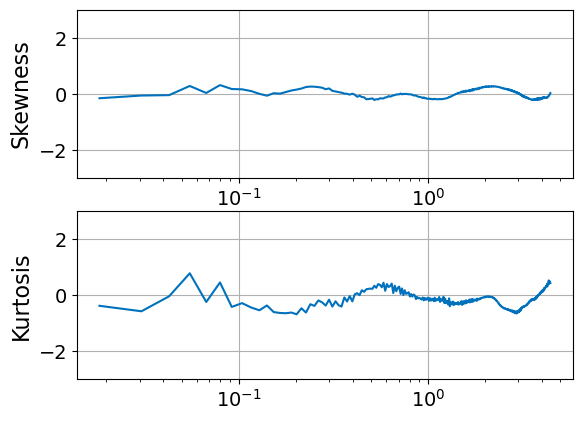

In [8]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

plt.subplot(2,1,1)
plt.semilogx(R, skew(SF3, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul')
plt.ylim([-3,3])
plt.grid(True)
plt.ylabel('Skewness')

plt.subplot(2,1,2)
plt.semilogx(R, kurtosis(SF3, fisher=True, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul hf')
plt.ylim([-3,3])
plt.grid(True)
plt.ylabel('Kurtosis')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_skew_kurt.png', dpi=300, bbox_inches='tight')

# load Lag

In [9]:
data=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg2_sf1.mat')
sf1=-np.nanmean(data['SF1l_time']+data['SF1t_time'],axis=1)
dist_axis=np.squeeze(data['dist_axis'])

Text(0.5, 0, 'r')

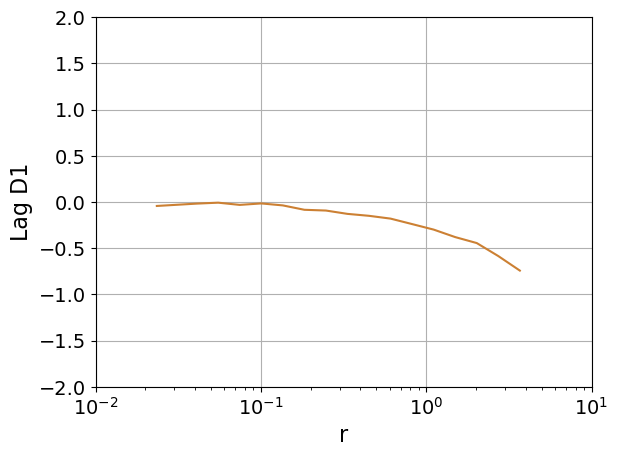

In [10]:
plt.semilogx(dist_axis,sf1,color=(0.8, 0.5, 0.2))
plt.ylim([-2,2])
plt.xlim(([1e-2,1e1]))
plt.grid(True)
plt.ylabel(r'Lag D1')
plt.xlabel(r'r')
# plt.title(r'HIT2d')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_lag_homogeneity.png', dpi=300, bbox_inches='tight')

In [11]:
sf3=(data['SF3lll_time']+data['SF3ltt_time']).T


In [12]:
D3bx = 0.55
D3b_bins_Lag = np.arange(-12, 12, D3bx)
iu3=7
sf3_Lag_norm0 = norm.pdf(D3b_bins, np.nanmean(sf3[:,iu3])/np.nanstd(sf3[:,iu3]), 1)

In [13]:
D3b_bins.shape,sf3.shape

((44,), (101, 17))

In [14]:
dist_axis[7]

0.24745178019103764

Text(0, 0.4, 'r=0.25')

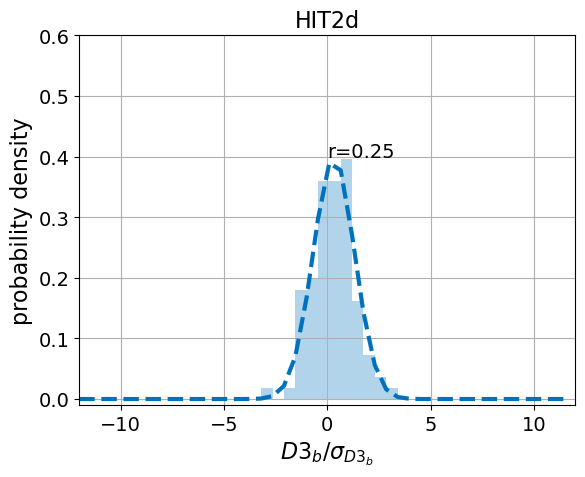

In [15]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

plt.plot(D3b_bins_Lag, sf3_Lag_norm0, linestyle='--',color=colorsmap[0],linewidth=3)
plt.hist((sf3[:,iu3])/np.nanstd(sf3[:,iu3]), bins=D3b_bins_Lag, alpha=0.3, density=True, color=colorsmap[0], label='Lag')

# plt.plot(D3b_bins, SF3_E_norm0, linestyle='--',color=colorsmap[0],linewidth=3)
# plt.hist((SF3[:,iu2])/np.nanstd(SF3[:,iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[0], label='Eulerian')
plt.ylim([-0.01,0.6])
plt.xlim([-12,12])
plt.ylabel(r'D1')
plt.xlabel(r'r')
plt.title(r'HIT2d')
plt.grid(True)
plt.xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
plt.ylabel(r'probability density')
plt.text(0,0.4,f'r=0.25')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_guassian.png', dpi=300, bbox_inches='tight')

Text(0, 0.5, 'Kurtosis')

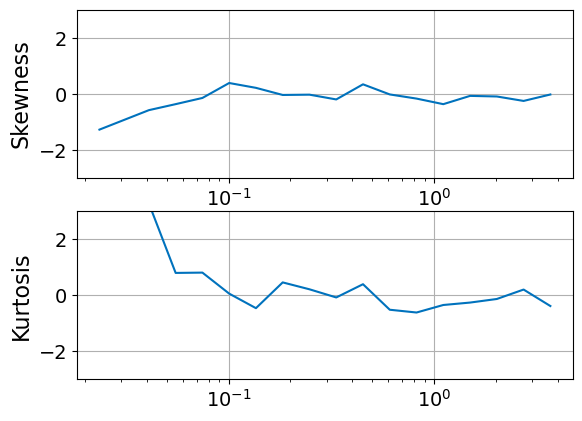

In [16]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

plt.subplot(2,1,1)
plt.semilogx(dist_axis, skew(sf3, axis=0), linewidth=1.5,color=colorsmap[0], label='Lag')
plt.ylim([-3,3])
plt.grid(True)
plt.ylabel('Skewness')

plt.subplot(2,1,2)
plt.semilogx(dist_axis, kurtosis(sf3, fisher=True, axis=0), linewidth=1.5,color=colorsmap[0], label='Lag')
plt.ylim([-3,3])
plt.grid(True)
plt.ylabel('Kurtosis')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_skew_kurt.png', dpi=300, bbox_inches='tight')

In [17]:
dist_axis.shape,sf3.shape

((17,), (101, 17))

# plot

In [18]:
DA=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_hit.mat')
SF1=np.squeeze(DA['SF1'])
R_check=np.squeeze(DA['R_check'])

In [19]:
data=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg2_sf1.mat')
sf1l=data['SF1l_time'].T
sf1t=data['SF1t_time'].T
dist_axis=np.squeeze(data['dist_axis'])
corr_L=temporal_correlation_per_scale(sf1l, sf1t)

da=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/HIT2d_corr_E.mat')
SF1_L_check=np.squeeze(da['SF1_L_check'])
SF1_T_check=np.squeeze(da['SF1_T_check'])
corr=temporal_correlation_per_scale(SF1_L_check, SF1_T_check)

/tmp/ipykernel_2834466/1095688174.py:228: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, _ = pearsonr(sf1l_valid, sf1t_valid)


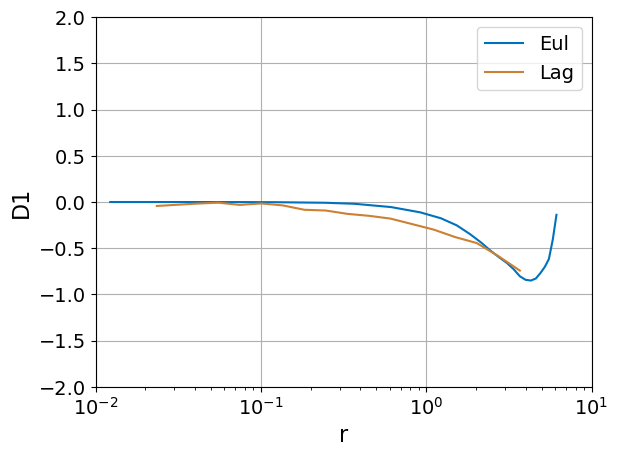

In [20]:
plt.semilogx(R_check,SF1,color=colorsmap[0],label='Eul')
plt.semilogx(dist_axis,sf1,color=(0.8, 0.5, 0.2),label='Lag')
plt.ylim([-2,2])
plt.xlim(([1e-2,1e1]))
plt.grid(True)
plt.ylabel(r'D1')
plt.xlabel(r'r')
plt.legend()
# plt.title(r'HIT2d')

Text(-5, 0.4, 'r=0.25')

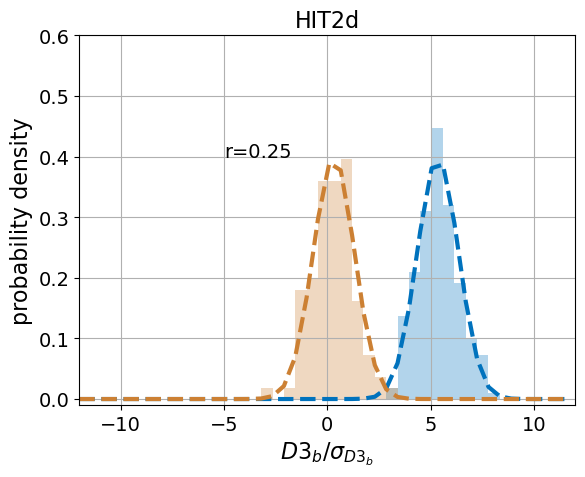

In [21]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
plt.plot(D3b_bins, SF3_E_norm0, linestyle='--',color=colorsmap[0],linewidth=3)
plt.hist((SF3[:,iu2])/np.nanstd(SF3[:,iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[0], label='Eulerian')

plt.plot(D3b_bins_Lag, sf3_Lag_norm0, linestyle='--',color=(0.8, 0.5, 0.2),linewidth=3)
plt.hist((sf3[:,iu3])/np.nanstd(sf3[:,iu3]), bins=D3b_bins_Lag, alpha=0.3, density=True, color=(0.8, 0.5, 0.2), label='Lag')
plt.ylim([-0.01,0.6])
plt.xlim([-12,12])
plt.ylabel(r'D1')
plt.xlabel(r'r')
plt.title(r'HIT2d')
plt.grid(True)
plt.xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
plt.ylabel(r'probability density')
plt.text(-5,0.4,f'r=0.25')

Text(0, 0.5, 'Kurtosis')

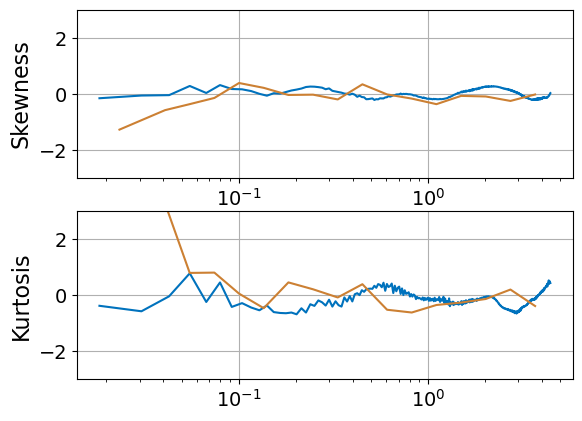

In [22]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

plt.subplot(2,1,1)
plt.semilogx(R, skew(SF3, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul')
plt.semilogx(dist_axis, skew(sf3, axis=0), linewidth=1.5,color=(0.8, 0.5, 0.2), label='Lag')
plt.ylim([-3,3])
plt.grid(True)
plt.ylabel('Skewness')

plt.subplot(2,1,2)
plt.semilogx(R, kurtosis(SF3, fisher=True, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul')
plt.semilogx(dist_axis, kurtosis(sf3, fisher=True, axis=0), linewidth=1.5,color=(0.8, 0.5, 0.2), label='Lag')

plt.ylim([-3,3])
plt.grid(True)
plt.ylabel('Kurtosis')

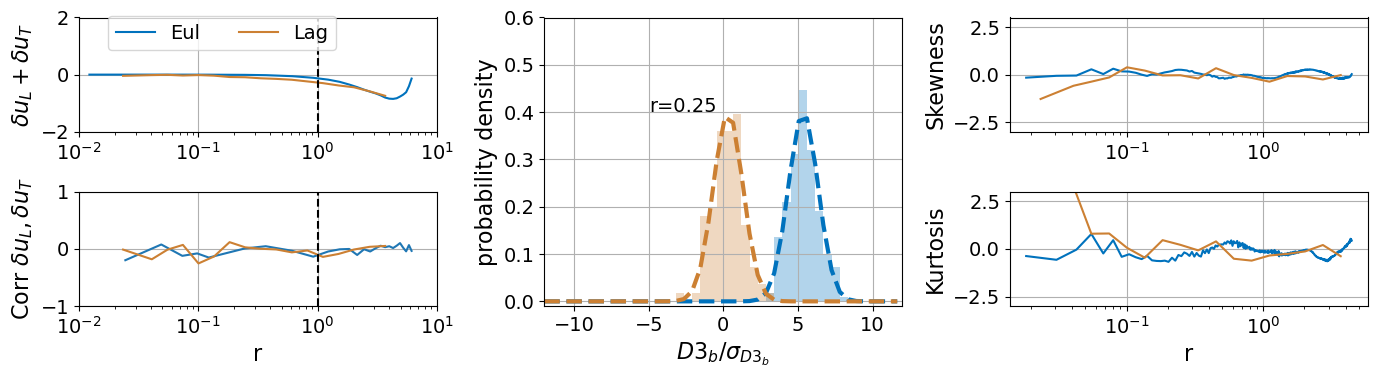

In [23]:
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import numpy as np

# 设置全局字体参数
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# 创建2行3列的子图，调整高度比例
fig = plt.figure(figsize=(14, 4))
gs = fig.add_gridspec(2, 3)

# 第一个子图：D1结构函数（占据第一行前两列）
ax1 = fig.add_subplot(gs[0:1, 0])  
ax1.semilogx(R_check, SF1, color=colorsmap[0], label='Eul')
ax1.semilogx(dist_axis, sf1, color=(0.8, 0.5, 0.2), label='Lag')
ax1.set_ylim([-2, 2])
ax1.plot([1e0,1e0],[-2,2],color='k',linestyle='--')
ax1.set_xlim([1e-2, 1e1])
ax1.grid(True)
ax1.set_ylabel(r'$\delta u_{L}+ \delta u_{T}$')
# ax1.set_xlabel(r'r')
# ax1.legend()
ax1.legend(loc='upper center', bbox_to_anchor=(0.4, 1.10), ncol=2)  # 移到上方


ax11 = fig.add_subplot(gs[1:2, 0])  
ax11.semilogx(R_check,corr)
ax11.semilogx(dist_axis,corr_L,color=(0.8, 0.5, 0.2))
ax11.plot([1e0,1e0],[-1,1],color='k',linestyle='--')
ax11.set_ylim(([-1,1]))
ax11.set_xlim(([1e-2,1e1]))
ax11.grid(True)
ax11.set_ylabel(r'Corr $\delta u_{L}, \delta u_{T}$')
ax11.set_xlabel(r'r')

# 第二个子图：D3概率密度分布（占据第二行前两列）
ax2 = fig.add_subplot(gs[0:2, 1])  # 第二行，前两列合并
ax2.plot(D3b_bins, SF3_E_norm0, linestyle='--', color=colorsmap[0], linewidth=3)
ax2.hist((SF3[:, iu2])/np.nanstd(SF3[:, iu2]), bins=D3b_bins, alpha=0.3, density=True, 
         color=colorsmap[0], label='Eulerian')
ax2.plot(D3b_bins_Lag, sf3_Lag_norm0, linestyle='--', color=(0.8, 0.5, 0.2), linewidth=3)
ax2.hist((sf3[:, iu3])/np.nanstd(sf3[:, iu3]), bins=D3b_bins_Lag, alpha=0.3, density=True, 
         color=(0.8, 0.5, 0.2), label='Lag')
ax2.set_ylim([-0.01, 0.6])
ax2.set_xlim([-12, 12])
ax2.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax2.set_ylabel(r'probability density')
ax2.grid(True)
ax2.text(-5, 0.4, f'r=0.25')

# 第三个子图：偏度（占据第一行第三列）
ax3 = fig.add_subplot(gs[0, 2])  # 第一行，第三列
ax3.semilogx(R, skew(SF3, axis=0), linewidth=1.5, color=colorsmap[0], label='Eul')
ax3.semilogx(dist_axis, skew(sf3, axis=0), linewidth=1.5, color=(0.8, 0.5, 0.2), label='Lag')
ax3.set_ylim([-3, 3])
ax3.grid(True)
ax3.set_ylabel('Skewness')
# ax3.set_xlabel('r')
# ax3.set_title('Skewness')

# 第四个子图：峰度（占据第二行第三列）
ax4 = fig.add_subplot(gs[1, 2])  # 第二行，第三列
ax4.semilogx(R, kurtosis(SF3, fisher=True, axis=0), linewidth=1.5, color=colorsmap[0], label='Eul')
ax4.semilogx(dist_axis, kurtosis(sf3, fisher=True, axis=0), linewidth=1.5, 
             color=(0.8, 0.5, 0.2), label='Lag')
ax4.set_ylim([-3, 3])
ax4.grid(True)
ax4.set_ylabel('Kurtosis')
ax4.set_xlabel('r')
# ax4.set_title('Kurtosis')

# 调整子图间距
plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/fig_stat_hit2d_guassian.png', dpi=300, bbox_inches='tight')
plt.show()

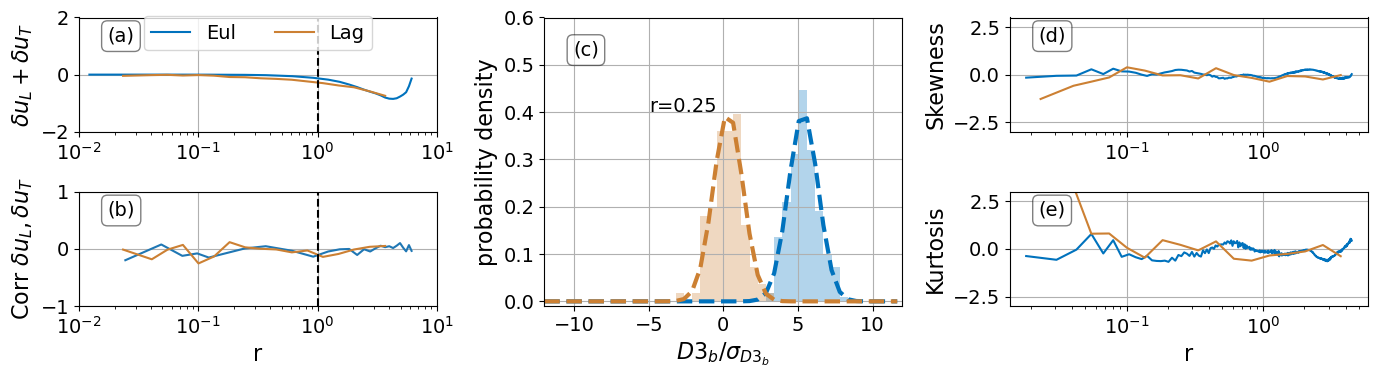

In [30]:
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import numpy as np

# 设置全局字体参数
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# 创建2行3列的子图，调整高度比例
fig = plt.figure(figsize=(14, 4))
gs = fig.add_gridspec(2, 3)

# 第一个子图：D1结构函数（占据第一行前两列）
ax1 = fig.add_subplot(gs[0:1, 0])  
ax1.semilogx(R_check, SF1, color=colorsmap[0], label='Eul')
ax1.semilogx(dist_axis, sf1, color=(0.8, 0.5, 0.2), label='Lag')
ax1.set_ylim([-2, 2])
ax1.plot([1e0,1e0],[-2,2],color='k',linestyle='--')
ax1.set_xlim([1e-2, 1e1])
ax1.grid(True)
ax1.set_ylabel(r'$\delta u_{L}+ \delta u_{T}$')
# ax1.set_xlabel(r'r')
# ax1.legend()
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=2)  # 移到上方

# 添加图例标签 (a) - 与第二个代码对齐
ax1.text(0.08, 0.92, '(a)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 半透明白色背景


ax11 = fig.add_subplot(gs[1:2, 0])  
ax11.semilogx(R_check,corr)
ax11.semilogx(dist_axis,corr_L,color=(0.8, 0.5, 0.2))
ax11.plot([1e0,1e0],[-1,1],color='k',linestyle='--')
ax11.set_ylim(([-1,1]))
ax11.set_xlim(([1e-2,1e1]))
ax11.grid(True)
ax11.set_ylabel(r'Corr $\delta u_{L}, \delta u_{T}$')
ax11.set_xlabel(r'r')

# 添加图例标签 (b) - 与第二个代码对齐
ax11.text(0.08, 0.92, '(b)', transform=ax11.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 半透明白色背景

# 第二个子图：D3概率密度分布（占据第二行前两列）
ax2 = fig.add_subplot(gs[0:2, 1])  # 第二行，前两列合并
ax2.plot(D3b_bins, SF3_E_norm0, linestyle='--', color=colorsmap[0], linewidth=3)
ax2.hist((SF3[:, iu2])/np.nanstd(SF3[:, iu2]), bins=D3b_bins, alpha=0.3, density=True, 
         color=colorsmap[0], label='Eulerian')
ax2.plot(D3b_bins_Lag, sf3_Lag_norm0, linestyle='--', color=(0.8, 0.5, 0.2), linewidth=3)
ax2.hist((sf3[:, iu3])/np.nanstd(sf3[:, iu3]), bins=D3b_bins_Lag, alpha=0.3, density=True, 
         color=(0.8, 0.5, 0.2), label='Lag')
ax2.set_ylim([-0.01, 0.6])
ax2.set_xlim([-12, 12])
ax2.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax2.set_ylabel(r'probability density')
ax2.grid(True)
ax2.text(-5, 0.4, f'r=0.25')

# 添加图例标签 (c) - 与第二个代码对齐
ax2.text(0.08, 0.92, '(c)', transform=ax2.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 半透明白色背景

# 第三个子图：偏度（占据第一行第三列）
ax3 = fig.add_subplot(gs[0, 2])  # 第一行，第三列
ax3.semilogx(R, skew(SF3, axis=0), linewidth=1.5, color=colorsmap[0], label='Eul')
ax3.semilogx(dist_axis, skew(sf3, axis=0), linewidth=1.5, color=(0.8, 0.5, 0.2), label='Lag')
ax3.set_ylim([-3, 3])
ax3.grid(True)
ax3.set_ylabel('Skewness')
# ax3.set_xlabel('r')
# ax3.set_title('Skewness')

# 添加图例标签 (d) - 与第二个代码对齐
ax3.text(0.08, 0.92, '(d)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 半透明白色背景

# 第四个子图：峰度（占据第二行第三列）
ax4 = fig.add_subplot(gs[1, 2])  # 第二行，第三列
ax4.semilogx(R, kurtosis(SF3, fisher=True, axis=0), linewidth=1.5, color=colorsmap[0], label='Eul')
ax4.semilogx(dist_axis, kurtosis(sf3, fisher=True, axis=0), linewidth=1.5, 
             color=(0.8, 0.5, 0.2), label='Lag')
ax4.set_ylim([-3, 3])
ax4.grid(True)
ax4.set_ylabel('Kurtosis')
ax4.set_xlabel('r')
# ax4.set_title('Kurtosis')

# 添加图例标签 (e) - 与第二个代码对齐
ax4.text(0.08, 0.92, '(e)', transform=ax4.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 半透明白色背景

# 调整子图间距
plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/fig_stat_hit2d_guassian.png', dpi=300, bbox_inches='tight')
plt.show()